In [ ]:
# Extract the compressed dataset file
!unzip archive.zip

Archive:  archive.zip
  inflating: test/disgust/PrivateTest_11895083.jpg  
  inflating: test/disgust/PrivateTest_19671520.jpg  
  inflating: test/disgust/PrivateTest_21629266.jpg  
  inflating: test/disgust/PrivateTest_22382996.jpg  
  inflating: test/disgust/PrivateTest_26306320.jpg  
  inflating: test/disgust/PrivateTest_29901781.jpg  
  inflating: test/disgust/PrivateTest_30523217.jpg  
  inflating: test/disgust/PrivateTest_34013087.jpg  
  inflating: test/disgust/PrivateTest_34426922.jpg  
  inflating: test/disgust/PrivateTest_36627671.jpg  
  inflating: test/disgust/PrivateTest_36724992.jpg  
  inflating: test/disgust/PrivateTest_3838250.jpg  
  inflating: test/disgust/PrivateTest_38750068.jpg  
  inflating: test/disgust/PrivateTest_3881740.jpg  
  inflating: test/disgust/PrivateTest_3929526.jpg  
  inflating: test/disgust/PrivateTest_40016880.jpg  
  inflating: test/disgust/PrivateTest_4396496.jpg  
  inflating: test/disgust/PrivateTest_4407805.jpg  
  inflating: test/disgust/Pri

In [ ]:
# Import shutil library to delete folders and their contents
import shutil

# List of emotion folders to remove from the dataset
folders_to_remove = ['angry', 'disgust', 'fear', 'neutral', 'surprise']

# Remove unwanted emotion folders from the training dataset
for folder in folders_to_remove:
    shutil.rmtree(f"train/{folder}", ignore_errors=True)

# Remove unwanted emotion folders from the testing dataset
for folder in folders_to_remove:
    shutil.rmtree(f"test/{folder}", ignore_errors=True)

# Print confirmation message after deletion process is completed
print("Done")

Done


In [ ]:
# Display the folders/files inside the training dataset directory
!ls train

# Display the folders/files inside the testing dataset directory
!ls test

happy  sad
happy  sad


In [ ]:
# Import TensorFlow library for building and training deep learning models
import tensorflow as tf

# Import required modules for creating neural network layers and models
from tensorflow.keras import layers, models

# Load training dataset from directory and automatically label images based on folder names
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "train",               # path to training data folder
    image_size=(48, 48),   # resize all images to 48x48 pixels
    batch_size=32          # number of images per batch
)

# Load testing dataset from directory and automatically label images based on folder names
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "test",                # path to testing data folder
    image_size=(48, 48),   # resize all images to 48x48 pixels
    batch_size=32          # number of images per batch
)

Found 12045 files belonging to 2 classes.
Found 3021 files belonging to 2 classes.


In [ ]:
# Create a normalization layer to scale pixel values from [0, 255] to [0, 1]
normalization_layer = layers.Rescaling(1./255)

# Apply normalization to the training dataset images
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

# Apply normalization to the testing dataset images
test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

In [ ]:
# Build a Sequential CNN model for image classification
model = models.Sequential([

    # First convolution layer: extracts 32 feature maps using 3x3 filters
    # Input shape is 48x48 images with 3 color channels (RGB)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 3)),

    # Reduce spatial dimensions to reduce computation and keep important features
    layers.MaxPooling2D(2, 2),

    # Second convolution layer: learns more complex features (64 filters)
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Downsampling again using max pooling
    layers.MaxPooling2D(2, 2),

    # Third convolution layer: deeper feature extraction (128 filters)
    layers.Conv2D(128, (3, 3), activation='relu'),

    # Further spatial reduction
    layers.MaxPooling2D(2, 2),

    # Convert 2D feature maps into 1D vector for dense layers
    layers.Flatten(),

    # Fully connected layer to learn high-level patterns
    layers.Dense(128, activation='relu'),

    # Dropout layer to reduce overfitting by randomly disabling neurons
    layers.Dropout(0.5),

    # Output layer with 2 classes (binary classification) using softmax
    layers.Dense(2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the CNN model by defining optimizer, loss function, and evaluation metric
model.compile(
    optimizer='adam',  # Adaptive optimizer for efficient training
    loss='sparse_categorical_crossentropy',  # Suitable for integer-labeled multi-class classification
    metrics=['accuracy']  # Track accuracy during training and evaluation
)

In [ ]:
# Train the CNN model using the training dataset
# and validate its performance using the test dataset
history = model.fit(
    train_ds,                 # training data
    validation_data=test_ds,  # validation (testing) data
    epochs=10                 # number of training iterations over the dataset
)

Epoch 1/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - accuracy: 0.6664 - loss: 0.6060 - val_accuracy: 0.7501 - val_loss: 0.4877
Epoch 2/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 47s 126ms/step - accuracy: 0.7926 - loss: 0.4360 - val_accuracy: 0.8226 - val_loss: 0.3772
Epoch 3/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 47s 125ms/step - accuracy: 0.8372 - loss: 0.3610 - val_accuracy: 0.8219 - val_loss: 0.3720
Epoch 4/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 47s 125ms/step - accuracy: 0.8587 - loss: 0.3216 - val_accuracy: 0.8418 - val_loss: 0.3469
Epoch 5/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 49s 130ms/step - accuracy: 0.8763 - loss: 0.2887 - val_accuracy: 0.8560 - val_loss: 0.3264
Epoch 6/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 79s 123ms/step - accuracy: 0.8914 - loss: 0.2593 - val_accuracy: 0.8454 - val_loss: 0.3405
Epoch 7/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 48s 127ms/step - accuracy: 0.9007 - loss: 0.2325 - val_accuracy: 0.8613 - val_loss: 0.3345
Epoch 8/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 46s 123ms/step - accuracy: 0.9200 - loss: 0

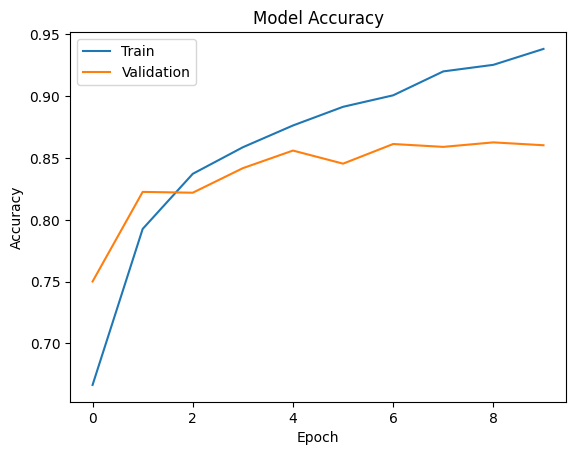

In [ ]:
# Import matplotlib library for plotting graphs
import matplotlib.pyplot as plt

# Plot training accuracy over epochs
plt.plot(history.history['accuracy'])

# Plot validation accuracy over epochs
plt.plot(history.history['val_accuracy'])

# Set the title of the graph
plt.title('Model Accuracy')

# Label Y-axis as Accuracy
plt.ylabel('Accuracy')

# Label X-axis as Epochs
plt.xlabel('Epoch')

# Add legend to distinguish training and validation curves
plt.legend(['Train', 'Validation'])

# Display the plot
plt.show()

In [ ]:
# Import pre-trained MobileNetV2 model for transfer learning
from tensorflow.keras.applications import MobileNetV2

# Import required layers and model API from Keras
from tensorflow.keras import layers, models

# Load MobileNetV2 model pre-trained on ImageNet dataset
# include_top=False removes the final classification layer
base_model = MobileNetV2(
   input_shape=(48, 48, 3),   # input image size (48x48 RGB)
   include_top=False,         # exclude default classifier head
   weights='imagenet'         # use pre-trained ImageNet weights
)

# Freeze the base model so its weights are not updated during training
base_model.trainable = False

/tmp/ipykernel_6085/1729882502.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Build a transfer learning model using the pre-trained MobileNetV2 base
pretrained_model = models.Sequential([

   # Pre-trained convolutional base (feature extractor)
   base_model,

   # Convert feature maps into a single vector per image
   layers.GlobalAveragePooling2D(),

   # Fully connected layer to learn new patterns for our dataset
   layers.Dense(128, activation='relu'),

   # Dropout layer to reduce overfitting
   layers.Dropout(0.5),

   # Output layer for 2-class classification (softmax gives probabilities)
   layers.Dense(2, activation='softmax')
])

In [ ]:
# Compile the transfer learning model (MobileNetV2 + custom layers)
pretrained_model.compile(
   optimizer='adam',  # optimizer that adapts learning rate automatically
   loss='sparse_categorical_crossentropy',  # loss function for integer-based multi-class labels
   metrics=['accuracy']  # evaluate model performance using accuracy
)

In [ ]:
# Train the transfer learning model using the training dataset
# and validate it using the test dataset
history_pretrained = pretrained_model.fit(

    train_ds,                  # training dataset
    validation_data=test_ds,   # validation/testing dataset
    epochs=10                  # number of training epochs
)

Epoch 1/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 42s 96ms/step - accuracy: 0.6460 - loss: 0.6583 - val_accuracy: 0.6822 - val_loss: 0.5972
Epoch 2/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 35s 94ms/step - accuracy: 0.6982 - loss: 0.5831 - val_accuracy: 0.6862 - val_loss: 0.5845
Epoch 3/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.7160 - loss: 0.5531 - val_accuracy: 0.6925 - val_loss: 0.5850
Epoch 4/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 34s 90ms/step - accuracy: 0.7358 - loss: 0.5294 - val_accuracy: 0.6882 - val_loss: 0.5723
Epoch 5/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 38s 102ms/step - accuracy: 0.7530 - loss: 0.5082 - val_accuracy: 0.6822 - val_loss: 0.5813
Epoch 6/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 35s 93ms/step - accuracy: 0.7656 - loss: 0.4843 - val_accuracy: 0.6885 - val_loss: 0.5910
Epoch 7/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 34s 89ms/step - accuracy: 0.7780 - loss: 0.4598 - val_accuracy: 0.6912 - val_loss: 0.5930
Epoch 8/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 39s 103ms/step - accuracy: 0.8004 - loss: 0.4320 

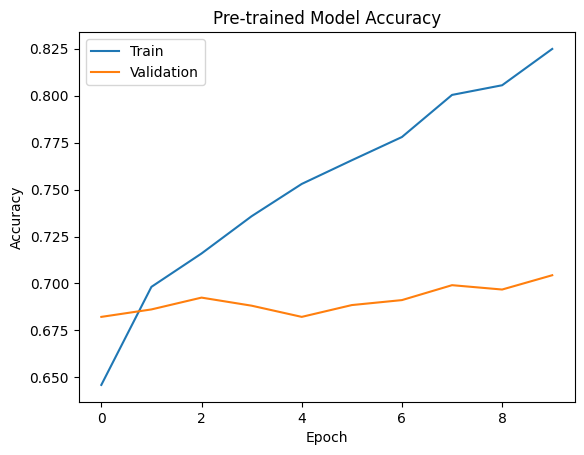

In [ ]:
# Import matplotlib for plotting training results
import matplotlib.pyplot as plt

# Plot training accuracy of the pre-trained model over epochs
plt.plot(history_pretrained.history['accuracy'])

# Plot validation accuracy of the pre-trained model over epochs
plt.plot(history_pretrained.history['val_accuracy'])

# Set plot title
plt.title('Pre-trained Model Accuracy')

# Label Y-axis
plt.ylabel('Accuracy')

# Label X-axis
plt.xlabel('Epoch')

# Add legend to distinguish curves
plt.legend(['Train', 'Validation'])

# Display the plot
plt.show()

In [ ]:
# Import precision score metric from sklearn
from sklearn.metrics import precision_score

# Import NumPy for array manipulation
import numpy as np

# Extract true labels from the test dataset
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Predict class probabilities using the trained model
y_pred = model.predict(test_ds)

# Convert predicted probabilities into class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate weighted precision score
precision = precision_score(y_true, y_pred_classes, average='weighted')

# Print final precision result
print("Precision:", precision)

95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step
Precision: 0.5192499288510941


In [ ]:
# Import precision metric from sklearn
from sklearn.metrics import precision_score

# Import NumPy for array operations
import numpy as np

# Extract true labels from the test dataset
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Get predictions from the pre-trained model
y_pred_pretrained = pretrained_model.predict(test_ds)

# Convert prediction probabilities to class labels
y_pred_classes_pretrained = np.argmax(y_pred_pretrained, axis=1)

# Calculate weighted precision score for pre-trained model
precision_pretrained = precision_score(
   y_true,
   y_pred_classes_pretrained,
   average='binary',
   pos_label=1
)

# Print final precision result for pre-trained model
print("Pre-trained Precision:", precision_pretrained)

95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step
Pre-trained Precision: 0.4159592529711375


In [ ]:
# Save the trained CNN model to a file in HDF5 format
model.save("emotion_model.h5")